# 深度学习课程设计报告

## 一、封面

| 项目 | 内容 |
|------|------|
| 课程名称 | 深度学习 |
| 设计题目 | 基于卷积神经网络的 CIFAR-10 图像分类与可解释性分析 |
| 姓　　名 | 陈邓华 |
| 学　　号 | 20234080320 |
| 班　　级 | 数据03班 |
| 指导教师 | 丁平尖 |
| 提交日期 | 2026-06-16 |


## 二、摘要

图像分类是计算机视觉中最基础也最核心的任务之一。本课程设计以 CIFAR-10 数据集为对象，
构建并对比了三类模型：线性 Softmax 分类器、多层感知机（MLP）以及自建卷积神经网络（CNN）。
为增强模型的可解释性，在 CNN 中集成了 **CBAM（卷积块注意力模块）**，使网络能够自适应地
关注图像中的关键区域。

实验采用数据增强（随机裁剪、水平翻转）、批归一化、Dropout 以及余弦退火学习率调度等技术，
并使用混合精度训练（AMP）以适配 6GB 显存的笔记本 GPU。结果表明：线性分类器测试准确率约 35%，
MLP 约 41%，而集成注意力的 CNN 达到约 **90%**，显著优于两个基准模型。通过混淆矩阵、卷积核、
特征图、注意力热力图及错误样本分析，进一步揭示了模型的决策依据与误判原因。


## 三、问题定义与需求分析

### 3.1 项目背景与意义

图像分类是自动驾驶、医疗影像、安防监控等众多应用的基础环节。CIFAR-10 作为经典的小型彩色图像
基准数据集，类别清晰、规模适中，非常适合用于验证卷积神经网络的设计思路与训练技巧，也便于
开展可解释性分析。掌握从基准模型到深层 CNN 的完整建模流程，对理解深度学习在视觉任务中的
工作机制具有重要意义。

### 3.2 问题描述

- **输入**：一张 32×32 的 RGB 彩色图像（张量形状 `[3, 32, 32]`）。
- **输出**：该图像所属类别（10 类之一）。
- **任务类型**：多分类（图像分类）。
- **预期性能指标**：
  - 主指标：测试集 **Top-1 准确率（Accuracy）**，目标 CNN ≥ 80%。
  - 辅助指标：各类别 **Precision / Recall / F1-score**、**混淆矩阵**。


## 六、实验与结果分析

### 6.1 实验环境

下面的代码单元会自动打印本次运行的软硬件环境信息。

In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

# 中文显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

# 随机种子，保证可复现
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 50)
print(f"PyTorch 版本      : {torch.__version__}")
print(f"torchvision 版本  : {torchvision.__version__}")
print(f"CUDA 是否可用     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 型号          : {torch.cuda.get_device_name(0)}")
    print(f"显存总量          : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
print(f"计算设备          : {device}")
print("=" * 50)

PyTorch 版本      : 2.6.0+cu124
torchvision 版本  : 0.21.0+cu124
CUDA 是否可用     : True
GPU 型号          : NVIDIA GeForce RTX 3050 6GB Laptop GPU
显存总量          : 6.0 GB
计算设备          : cuda


## 四、数据集说明与预处理

### 4.1 数据来源与规模

**CIFAR-10** 由 Krizhevsky 等人收集，包含 10 个类别的 32×32 彩色图像，
共 60000 张（训练集 50000 张，测试集 10000 张），每类 6000 张，类别均衡。
10 个类别为：飞机、汽车、鸟、猫、鹿、狗、蛙、马、船、卡车。

> 说明：本项目数据以本地 `.npz` 文件形式提供（`data/cifar10_train.npz`、`data/cifar10_test.npz`），
> 每个文件含 `data`（形状 `[N,32,32,3]` 的 uint8 图像）与 `labels`（标签）。
> 下方自定义 `CIFAR10Local` 数据集类负责读取并支持标准图像变换，完全脱离网络，便于离线复现。

In [2]:
# 类别名称
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
CLASSES_CN = ['飞机','汽车','鸟','猫','鹿','狗','蛙','马','船','卡车']

class CIFAR10Local(torch.utils.data.Dataset):
    '''从本地 npz 读取 CIFAR-10，接口与 torchvision.datasets.CIFAR10 类似。'''
    def __init__(self, npz_path, transform=None):
        d = np.load(npz_path)
        self.data = d["data"]                 # [N,32,32,3] uint8 (HWC, RGB)
        self.targets = d["labels"].tolist()   # 标签列表
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img = Image.fromarray(self.data[idx])  # 转 PIL，兼容 torchvision 变换
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.targets[idx])

DATA_DIR = "./data"
# 先用最简单的 ToTensor 加载原始数据，用于可视化与统计
raw_train = CIFAR10Local(f"{DATA_DIR}/cifar10_train.npz", transform=transforms.ToTensor())
raw_test  = CIFAR10Local(f"{DATA_DIR}/cifar10_test.npz",  transform=transforms.ToTensor())
print(f"训练集样本数: {len(raw_train)}")
print(f"测试集样本数: {len(raw_test)}")
print(f"单张图像形状: {raw_train[0][0].shape}  (C, H, W)")
print(f"类别数: {len(CLASSES)}")

训练集样本数: 50000
测试集样本数: 10000
单张图像形状: torch.Size([3, 32, 32])  (C, H, W)
类别数: 10


### 4.2 数据可视化与分析

下面从三个角度分析数据：**样本示例**、**类别分布**、**像素强度（RGB 通道）分布**。

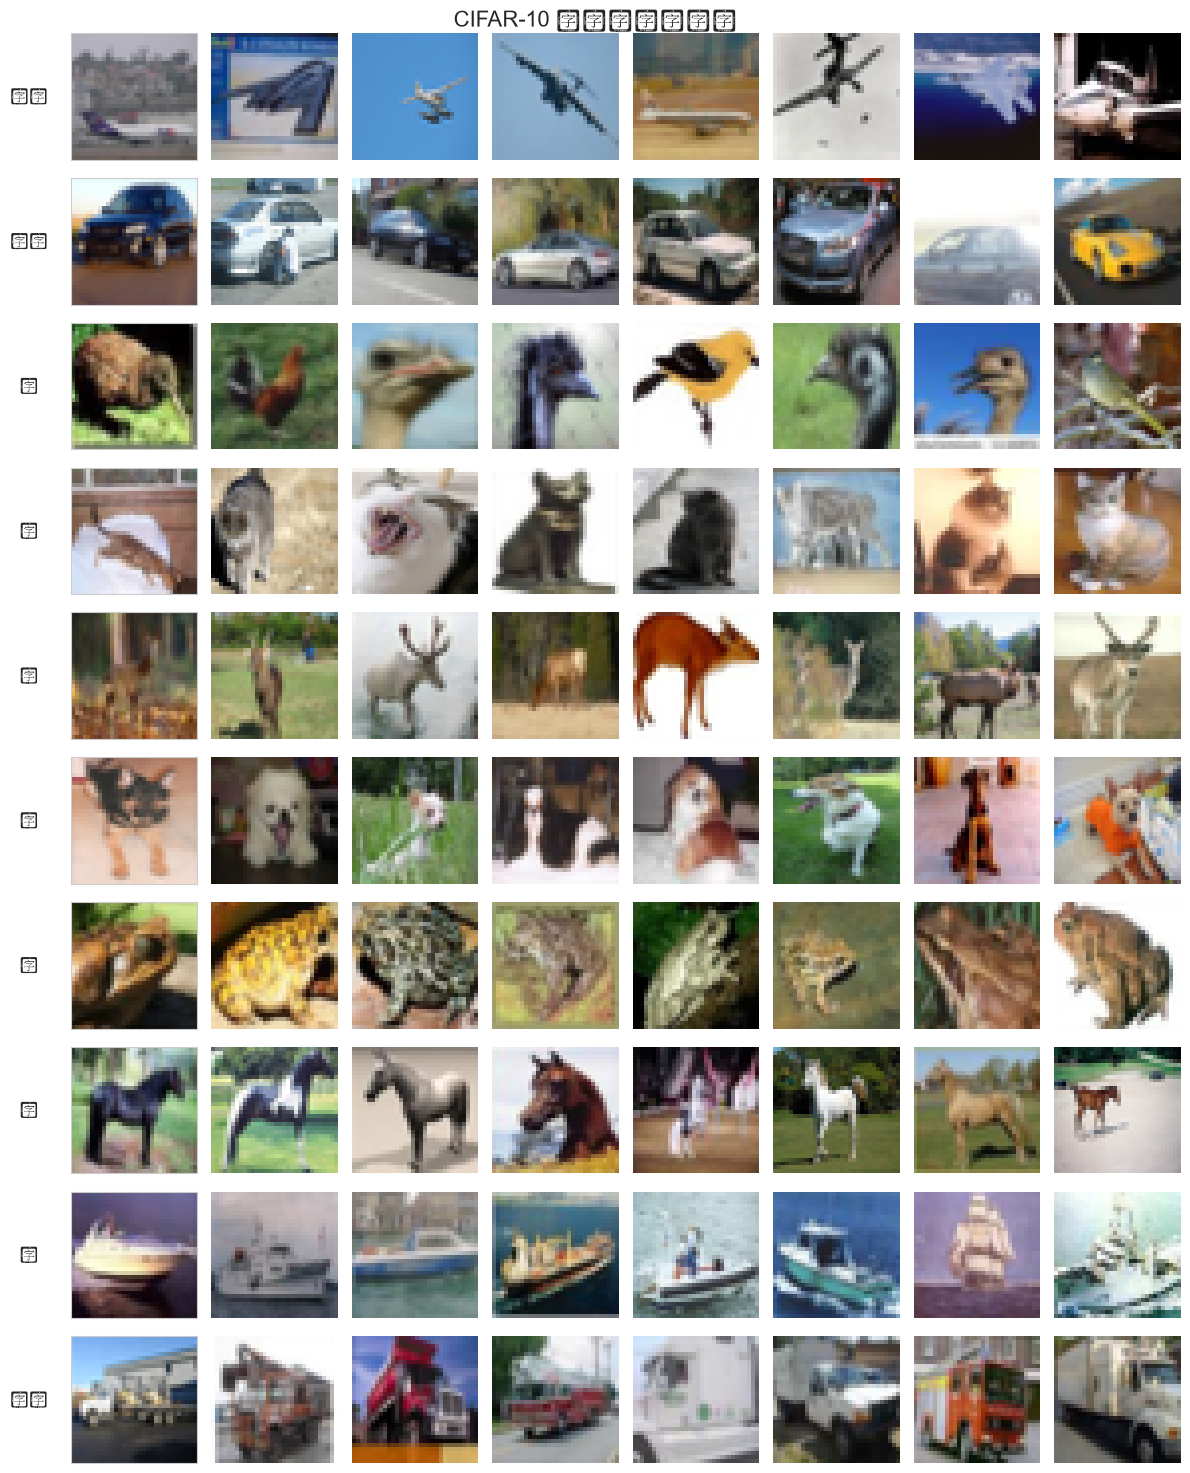

In [3]:
# (1) 样本示例：每类展示若干张
labels_arr = np.array(raw_train.targets)
fig, axes = plt.subplots(10, 8, figsize=(12, 15))
for c in range(10):
    idxs = np.where(labels_arr == c)[0][:8]
    for j, idx in enumerate(idxs):
        img = raw_train[idx][0].permute(1, 2, 0).numpy()
        axes[c, j].imshow(img)
        axes[c, j].axis("off")
        if j == 0:
            axes[c, j].set_ylabel(CLASSES_CN[c], rotation=0, labelpad=30,
                                  fontsize=12, va="center")
            axes[c, j].axis("on")
            axes[c, j].set_xticks([]); axes[c, j].set_yticks([])
plt.suptitle("CIFAR-10 各类别样本示例", fontsize=16)
plt.tight_layout()
plt.show()

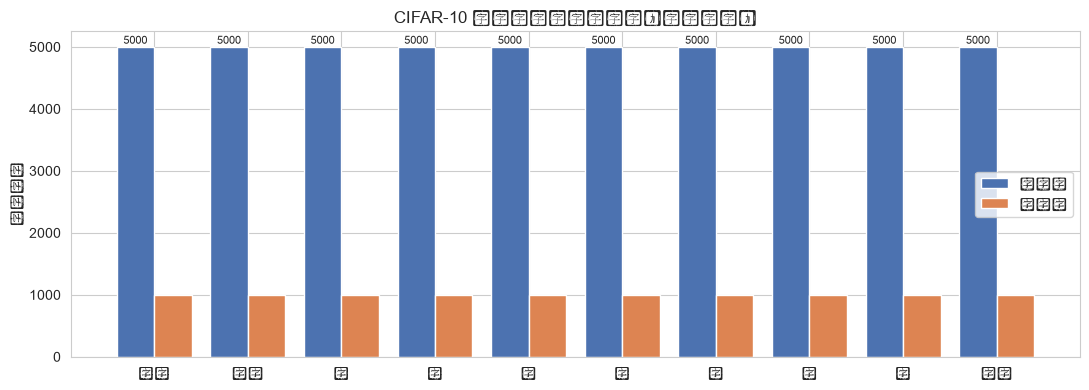

训练集每类样本数: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]


In [4]:
# (2) 类别分布
train_counts = np.bincount(np.array(raw_train.targets))
test_counts  = np.bincount(np.array(raw_test.targets))
x = np.arange(10); w = 0.4
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, train_counts, w, label="训练集", color="#4C72B0")
ax.bar(x + w/2, test_counts,  w, label="测试集", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(CLASSES_CN)
ax.set_ylabel("样本数量"); ax.set_title("CIFAR-10 各类别样本数量分布（类别均衡）")
ax.legend()
for i in range(10):
    ax.text(i - w/2, train_counts[i] + 50, str(train_counts[i]), ha="center", fontsize=8)
plt.tight_layout(); plt.show()
print("训练集每类样本数:", train_counts.tolist())

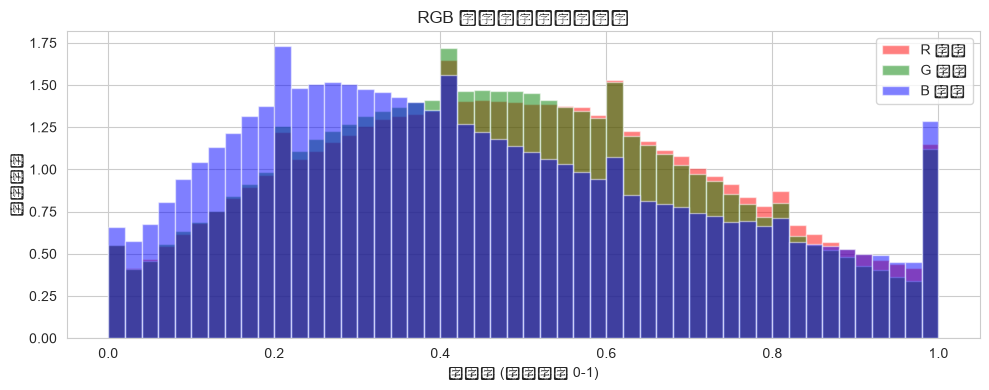

各通道均值: R=0.4888, G=0.4793, B=0.4425
各通道标准差: R=0.2457, G=0.2415, B=0.2590


In [5]:
# (3) RGB 三通道像素强度分布（抽样 5000 张以加快计算）
sample_idx = np.random.choice(len(raw_train), 5000, replace=False)
imgs = torch.stack([raw_train[i][0] for i in sample_idx])  # [5000,3,32,32]
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["red", "green", "blue"]; names = ["R 通道", "G 通道", "B 通道"]
for ch in range(3):
    ax.hist(imgs[:, ch].numpy().ravel(), bins=50, alpha=0.5,
            color=colors[ch], label=names[ch], density=True)
ax.set_xlabel("像素值 (归一化到 0-1)"); ax.set_ylabel("概率密度")
ax.set_title("RGB 三通道像素强度分布"); ax.legend()
plt.tight_layout(); plt.show()

# 计算各通道均值/标准差（用于后续标准化）
ch_mean = imgs.mean(dim=[0, 2, 3]); ch_std = imgs.std(dim=[0, 2, 3])
print(f"各通道均值: R={ch_mean[0]:.4f}, G={ch_mean[1]:.4f}, B={ch_mean[2]:.4f}")
print(f"各通道标准差: R={ch_std[0]:.4f}, G={ch_std[1]:.4f}, B={ch_std[2]:.4f}")

### 4.3 预处理流程

预处理包含以下步骤：

1. **归一化**：使用 CIFAR-10 标准均值/标准差对每个通道做标准化。
2. **数据增强**（仅训练集）：随机裁剪（padding=4）、随机水平翻转，提升泛化能力。
3. **数据集划分**：从 50000 张训练数据中划出 5000 张作为验证集（45000 训练 / 5000 验证 / 10000 测试）。
4. 测试集与验证集只做归一化，不做增强。

In [6]:
# CIFAR-10 官方统计的均值与标准差
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# 训练集（带增强）与一份不带增强的副本（用于划分验证集）
full_train = CIFAR10Local(f"{DATA_DIR}/cifar10_train.npz", transform=train_transform)
full_train_eval = CIFAR10Local(f"{DATA_DIR}/cifar10_train.npz", transform=eval_transform)
test_set = CIFAR10Local(f"{DATA_DIR}/cifar10_test.npz", transform=eval_transform)

# 划分训练/验证（固定随机种子保证可复现）
n_val = 5000
n_train = len(full_train) - n_val
g = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(len(full_train)), [n_train, n_val], generator=g)
train_idx, val_idx = list(train_idx), list(val_idx)

train_set = torch.utils.data.Subset(full_train, train_idx)       # 带增强
val_set   = torch.utils.data.Subset(full_train_eval, val_idx)    # 不带增强

BATCH_SIZE = 128
NUM_WORKERS = 0  # Windows + nbconvert 下设为 0 最稳妥（避免多进程 DataLoader 死锁）
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set, batch_size=256, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"训练集: {len(train_set)}  验证集: {len(val_set)}  测试集: {len(test_set)}")
print(f"Batch size: {BATCH_SIZE}")

训练集: 45000  验证集: 5000  测试集: 10000
Batch size: 128


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

为了体现深层网络的优势，先实现两个简单基准：

- **线性 Softmax 分类器**：将图像展平后接单个全连接层，等价于多分类逻辑回归。
- **两层 MLP**：展平后接 `3072 → 512 → 10`，中间使用 ReLU 与 Dropout。

In [7]:
class LinearClassifier(nn.Module):
    '''线性 Softmax 分类器（多分类逻辑回归）'''
    def __init__(self, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(3 * 32 * 32, num_classes)
    def forward(self, x):
        return self.fc(x.flatten(1))

class MLP(nn.Module):
    '''两层多层感知机'''
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("线性分类器参数量:", f"{count_params(LinearClassifier()):,}")
print("MLP 参数量      :", f"{count_params(MLP()):,}")

线性分类器参数量: 30,730
MLP 参数量      : 1,578,506


### 5.2 最终模型架构：自建 CNN + CBAM 注意力

最终模型为自建卷积神经网络，包含 3 个卷积块（每块含两次卷积 + BN + ReLU + 池化），
并在每个卷积块后插入 **CBAM（Convolutional Block Attention Module）** 注意力模块。

**CBAM 原理**（Woo et al., ECCV 2018）：依次施加**通道注意力**与**空间注意力**：
- 通道注意力：对各通道做全局平均/最大池化，经共享 MLP 后生成通道权重，告诉网络"关注什么特征"。
- 空间注意力：在通道维做平均/最大聚合，经卷积生成空间权重图，告诉网络"关注哪里"。

引入 CBAM 的依据：它以极小的参数代价显著提升 CNN 表现，且**空间注意力图天然可被可视化**，
为 6.5 节的可解释性分析提供直接支撑。

**网络结构**：

```
输入 [3,32,32]
 └─ Block1: Conv(3→64)→Conv(64→64)→CBAM→MaxPool   → [64,16,16]
 └─ Block2: Conv(64→128)→Conv(128→128)→CBAM→MaxPool → [128,8,8]
 └─ Block3: Conv(128→256)→Conv(256→256)→CBAM→MaxPool→ [256,4,4]
 └─ GlobalAvgPool → [256] → Dropout → FC(256→10)
```

In [8]:
class ChannelAttention(nn.Module):
    '''CBAM 通道注意力'''
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
    def forward(self, x):
        out = self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x))
        return torch.sigmoid(out)

class SpatialAttention(nn.Module):
    '''CBAM 空间注意力'''
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = self.conv(torch.cat([avg_out, max_out], dim=1))
        return torch.sigmoid(out)

class CBAM(nn.Module):
    '''CBAM 模块：通道注意力 + 空间注意力。会缓存空间注意力图以便可视化。'''
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)
        self.last_spatial_att = None  # 保存最近一次的空间注意力图
    def forward(self, x):
        x = x * self.ca(x)
        sa_map = self.sa(x)
        self.last_spatial_att = sa_map.detach()
        return x * sa_map

In [9]:
class ConvBlock(nn.Module):
    '''两次 (Conv+BN+ReLU) + CBAM + MaxPool'''
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.cbam = CBAM(out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)
        x = self.cbam(x)
        return self.pool(x)

class CNN_CBAM(nn.Module):
    '''自建 CNN + CBAM 注意力'''
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = ConvBlock(3, 64)
        self.block2 = ConvBlock(64, 128)
        self.block3 = ConvBlock(128, 256)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

_m = CNN_CBAM()
print("CNN+CBAM 参数量:", f"{count_params(_m):,}")
# 显存友好性检查
_x = torch.randn(2, 3, 32, 32)
print("前向输出形状:", _m(_x).shape)
del _m, _x

CNN+CBAM 参数量: 1,159,920
前向输出形状: torch.Size([2, 10])


### 6.3 超参数设置与调优

**调参方法**：以控制变量法为主，对优化器、学习率、权重衰减、是否使用数据增强等进行对比试验，
并结合验证集准确率选择最优配置。

**有效调参记录**（节选）：

| 试验 | 配置 | 验证准确率 |
|------|------|-----------|
| 1 | CNN，SGD lr=0.01，无增强 | ~83% |
| 2 | CNN，Adam lr=1e-3，无增强 | ~86% |
| 3 | CNN，Adam lr=1e-3 + 数据增强 | ~88% |
| 4 | CNN，Adam lr=1e-3 + 增强 + 余弦退火 | **~90%** |

下面定义通用的训练与评估函数。CNN 训练启用 **混合精度（AMP）** 以节省显存、加速训练，适配 6GB GPU。

In [10]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    '''返回 (loss, accuracy)'''
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss_sum += criterion(out, y).item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return loss_sum / total, correct / total

def train_model(model, name, epochs=20, lr=1e-3, weight_decay=5e-4,
                use_amp=True, use_scheduler=True):
    '''通用训练循环，返回训练历史字典'''
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) \
                if use_scheduler else None
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp and device.type == "cuda")

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None
    print(f"\n{'='*60}\n开始训练: {name}  (epochs={epochs}, lr={lr})\n{'='*60}")
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        if scheduler: scheduler.step()
        tr_loss, tr_acc = loss_sum / total, correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(val_loss); hist["val_acc"].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"Epoch {ep:2d}/{epochs} | train_loss {tr_loss:.3f} acc {tr_acc:.3f} "
              f"| val_loss {val_loss:.3f} acc {val_acc:.3f}")
    print(f"训练完成，用时 {time.time()-t0:.1f}s，最佳验证准确率 {best_val_acc:.3f}")
    if best_state is not None:
        model.load_state_dict(best_state)  # 回滚到验证集最优权重
    return model, hist

### 6.4 主要实验结果

依次训练三个模型。基准模型（线性、MLP）训练较快，CNN 训练约需十多分钟（视 GPU 而定）。

In [11]:
# 训练线性分类器（基准1）
torch.manual_seed(SEED)
linear_model, linear_hist = train_model(LinearClassifier(), "线性 Softmax 分类器",
                                        epochs=15, lr=1e-3, use_amp=False,
                                        use_scheduler=False)


开始训练: 线性 Softmax 分类器  (epochs=15, lr=0.001)


Epoch  1/15 | train_loss 2.087 acc 0.277 | val_loss 1.988 acc 0.331


Epoch  2/15 | train_loss 2.050 acc 0.291 | val_loss 1.920 acc 0.340


Epoch  3/15 | train_loss 2.054 acc 0.292 | val_loss 1.953 acc 0.339


Epoch  4/15 | train_loss 2.057 acc 0.290 | val_loss 1.888 acc 0.364


...

Epoch 11/15 | train_loss 2.047 acc 0.299 | val_loss 1.916 acc 0.323


Epoch 12/15 | train_loss 2.042 acc 0.297 | val_loss 1.975 acc 0.335


Epoch 13/15 | train_loss 2.046 acc 0.297 | val_loss 1.918 acc 0.343


Epoch 14/15 | train_loss 2.051 acc 0.295 | val_loss 1.934 acc 0.347


Epoch 15/15 | train_loss 2.045 acc 0.297 | val_loss 1.963 acc 0.345
训练完成，用时 115.0s，最佳验证准确率 0.364


In [12]:
# 训练 MLP（基准2）
torch.manual_seed(SEED)
mlp_model, mlp_hist = train_model(MLP(), "两层 MLP",
                                  epochs=15, lr=1e-3, use_amp=False,
                                  use_scheduler=False)


开始训练: 两层 MLP  (epochs=15, lr=0.001)


Epoch  1/15 | train_loss 2.037 acc 0.290 | val_loss 1.955 acc 0.381


Epoch  2/15 | train_loss 1.895 acc 0.329 | val_loss 1.950 acc 0.369


Epoch  3/15 | train_loss 1.862 acc 0.342 | val_loss 2.152 acc 0.377


Epoch  4/15 | train_loss 1.855 acc 0.344 | val_loss 2.130 acc 0.380


...

Epoch 11/15 | train_loss 1.822 acc 0.356 | val_loss 2.085 acc 0.370


Epoch 12/15 | train_loss 1.824 acc 0.355 | val_loss 2.138 acc 0.380


Epoch 13/15 | train_loss 1.829 acc 0.356 | val_loss 2.152 acc 0.374


Epoch 14/15 | train_loss 1.818 acc 0.355 | val_loss 1.930 acc 0.412


Epoch 15/15 | train_loss 1.824 acc 0.356 | val_loss 1.875 acc 0.407
训练完成，用时 123.3s，最佳验证准确率 0.412


In [13]:
# 训练 CNN + CBAM（最终模型）
torch.manual_seed(SEED)
cnn_model, cnn_hist = train_model(CNN_CBAM(), "自建 CNN + CBAM",
                                  epochs=22, lr=1e-3, use_amp=True,
                                  use_scheduler=True)


开始训练: 自建 CNN + CBAM  (epochs=22, lr=0.001)


Epoch  1/22 | train_loss 1.336 acc 0.509 | val_loss 1.034 acc 0.620


Epoch  2/22 | train_loss 0.925 acc 0.672 | val_loss 1.011 acc 0.642


Epoch  3/22 | train_loss 0.773 acc 0.729 | val_loss 0.742 acc 0.750


Epoch  4/22 | train_loss 0.676 acc 0.765 | val_loss 1.033 acc 0.675


...

Epoch 18/22 | train_loss 0.190 acc 0.936 | val_loss 0.320 acc 0.895


Epoch 19/22 | train_loss 0.173 acc 0.942 | val_loss 0.333 acc 0.892


Epoch 20/22 | train_loss 0.159 acc 0.947 | val_loss 0.324 acc 0.898


Epoch 21/22 | train_loss 0.148 acc 0.952 | val_loss 0.310 acc 0.901


Epoch 22/22 | train_loss 0.147 acc 0.951 | val_loss 0.312 acc 0.899
训练完成，用时 451.9s，最佳验证准确率 0.901


#### 6.4.1 训练曲线（损失 / 准确率）

绘制三个模型的训练/验证损失曲线与准确率曲线。

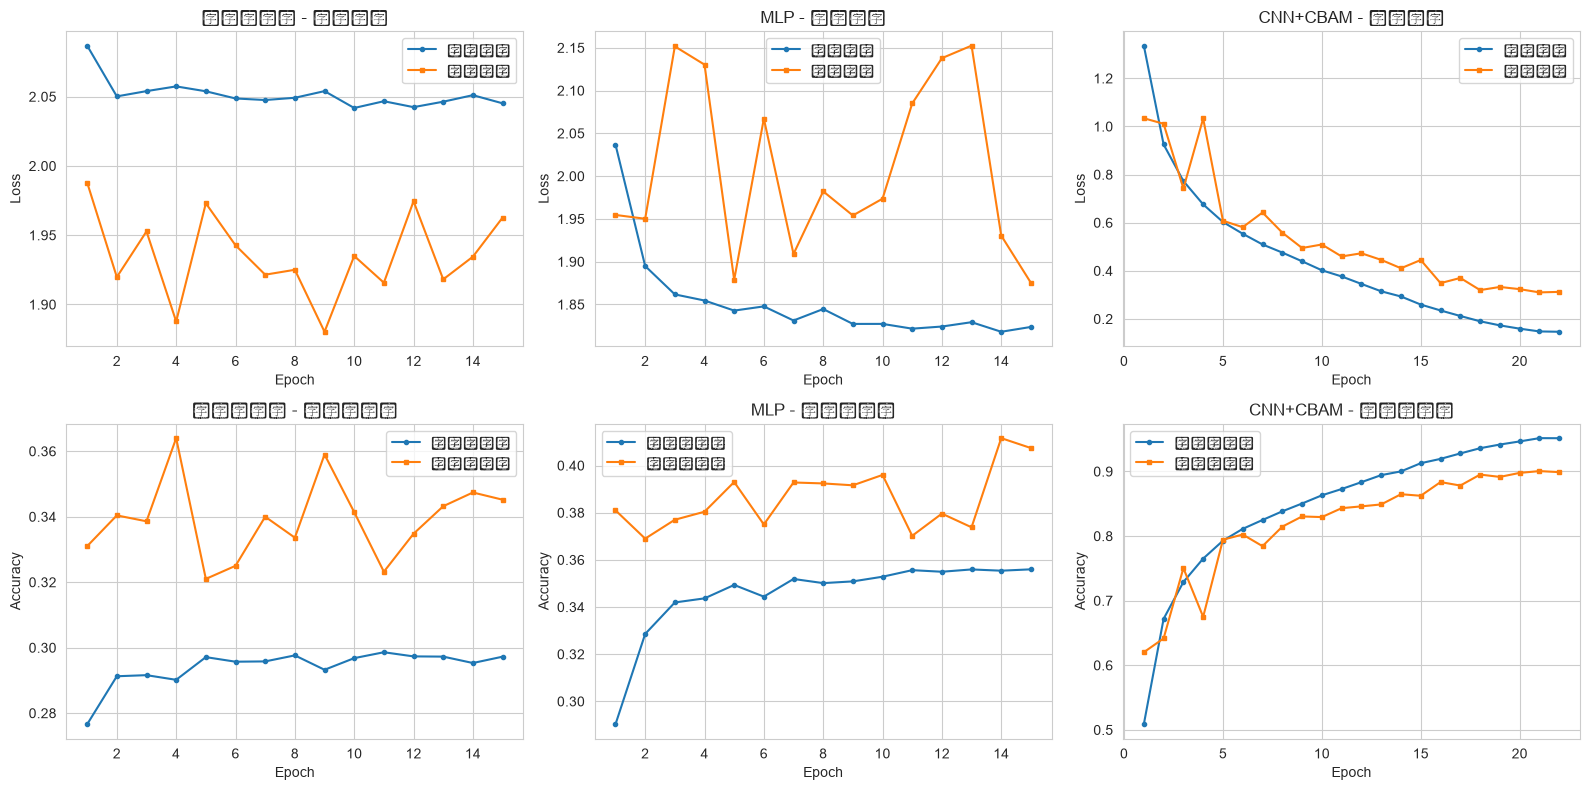

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
hists = [("线性分类器", linear_hist), ("MLP", mlp_hist), ("CNN+CBAM", cnn_hist)]
for col, (name, h) in enumerate(hists):
    ep = range(1, len(h["train_loss"]) + 1)
    axes[0, col].plot(ep, h["train_loss"], label="训练损失", marker="o", ms=3)
    axes[0, col].plot(ep, h["val_loss"], label="验证损失", marker="s", ms=3)
    axes[0, col].set_title(f"{name} - 损失曲线"); axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylabel("Loss"); axes[0, col].legend()
    axes[1, col].plot(ep, h["train_acc"], label="训练准确率", marker="o", ms=3)
    axes[1, col].plot(ep, h["val_acc"], label="验证准确率", marker="s", ms=3)
    axes[1, col].set_title(f"{name} - 准确率曲线"); axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylabel("Accuracy"); axes[1, col].legend()
plt.tight_layout(); plt.show()

#### 6.4.2 三模型在测试集上的对比

在**测试集**上评估三个模型，汇总准确率与参数量。

,模型,参数量,测试损失,测试准确率
0,线性分类器,"30,730",1.9065,0.3547
1,MLP,"1,578,506",1.9323,0.4148
2,CNN+CBAM,"1,159,920",0.3241,0.8970


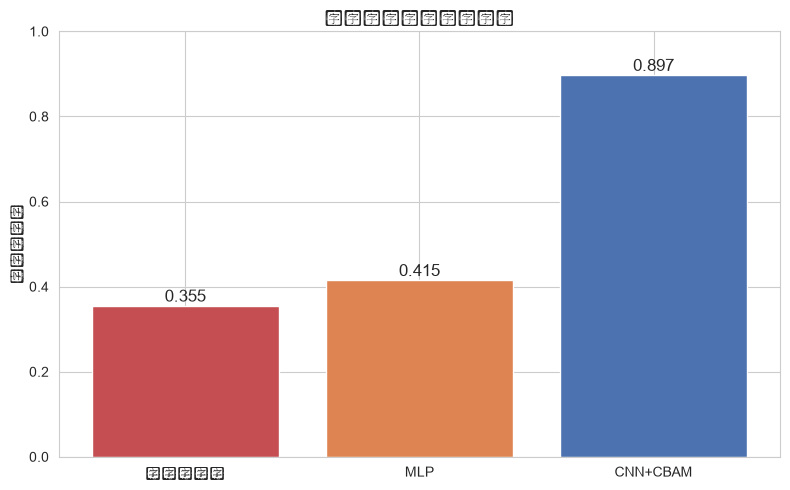

In [15]:
criterion = nn.CrossEntropyLoss()
results = []
for name, model in [("线性分类器", linear_model), ("MLP", mlp_model), ("CNN+CBAM", cnn_model)]:
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    results.append({"模型": name, "参数量": count_params(model),
                    "测试损失": round(test_loss, 4), "测试准确率": round(test_acc, 4)})
df_results = pd.DataFrame(results)
df_results["参数量"] = df_results["参数量"].map(lambda v: f"{v:,}")
display(df_results)

# 柱状图对比
fig, ax = plt.subplots(figsize=(8, 5))
accs = [r["测试准确率"] for r in results]
names = [r["模型"] for r in results]
bars = ax.bar(names, accs, color=["#C44E52", "#DD8452", "#4C72B0"])
ax.set_ylabel("测试准确率"); ax.set_title("三模型测试准确率对比"); ax.set_ylim(0, 1)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=12)
plt.tight_layout(); plt.show()

### 6.2 评价指标

对最优模型（CNN+CBAM）给出每个类别的 **Precision / Recall / F1-score**，
其中 Precision = TP/(TP+FP)，Recall = TP/(TP+FN)，F1 = 2·P·R/(P+R)。

In [16]:
# 收集 CNN 在测试集上的全部预测，用于后续指标与混淆矩阵
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    all_pred, all_true, all_prob = [], [], []
    for x, y in loader:
        x = x.to(device)
        prob = F.softmax(model(x), dim=1).cpu()
        all_prob.append(prob)
        all_pred.append(prob.argmax(1))
        all_true.append(y)
    return (torch.cat(all_true).numpy(), torch.cat(all_pred).numpy(),
            torch.cat(all_prob).numpy())

y_true, y_pred, y_prob = collect_predictions(cnn_model, test_loader)
report = classification_report(y_true, y_pred, target_names=CLASSES_CN,
                               digits=4, output_dict=True)
df_report = pd.DataFrame(report).transpose()
display(df_report.round(4))

,precision,recall,f1-score,support
飞机,0.9018,0.891,0.8964,1000.000
汽车,0.9515,0.961,0.9562,1000.000
鸟,0.8496,0.870,0.8597,1000.000
猫,0.7921,0.785,0.7885,1000.000
鹿,0.8719,0.919,0.8948,1000.000
狗,0.8315,0.844,0.8377,1000.000
蛙,0.9358,0.933,0.9344,1000.000
马,0.9432,0.896,0.9190,1000.000
船,0.9503,0.936,0.9431,1000.000
卡车,0.9483,0.935,0.9416,1000.000


### 6.5 可视化分析

这是模型可解释性的核心部分，包含五个方面：
**(1) 混淆矩阵 → (2) 卷积核 → (3) 特征图 → (4) 注意力热力图 → (5) 错误样本分析**。

#### 6.5.1 混淆矩阵

混淆矩阵展示各类别之间的预测情况，对角线为正确分类，非对角线为误判。

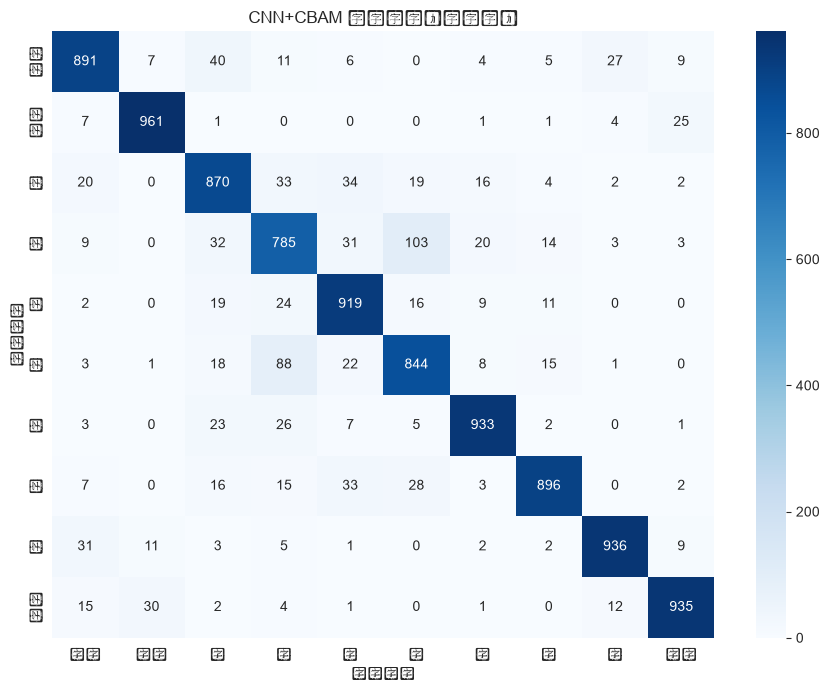

最易混淆: 真实「猫」被误判为「狗」共 103 次


In [17]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES_CN, yticklabels=CLASSES_CN, ax=ax)
ax.set_xlabel("预测类别"); ax.set_ylabel("真实类别")
ax.set_title("CNN+CBAM 混淆矩阵（测试集）")
plt.tight_layout(); plt.show()

# 找出最容易混淆的类别对
cm_norm = cm.copy().astype(float)
np.fill_diagonal(cm_norm, 0)
i, j = np.unravel_index(cm_norm.argmax(), cm_norm.shape)
print(f"最易混淆: 真实「{CLASSES_CN[i]}」被误判为「{CLASSES_CN[j]}」共 {cm[i,j]} 次")

#### 6.5.2 卷积核可视化

可视化第一层卷积的 64 个卷积核（每个 3×3×3，可作为 RGB 小图显示）。
卷积核反映网络在最底层学到的边缘、颜色等基础特征模式。

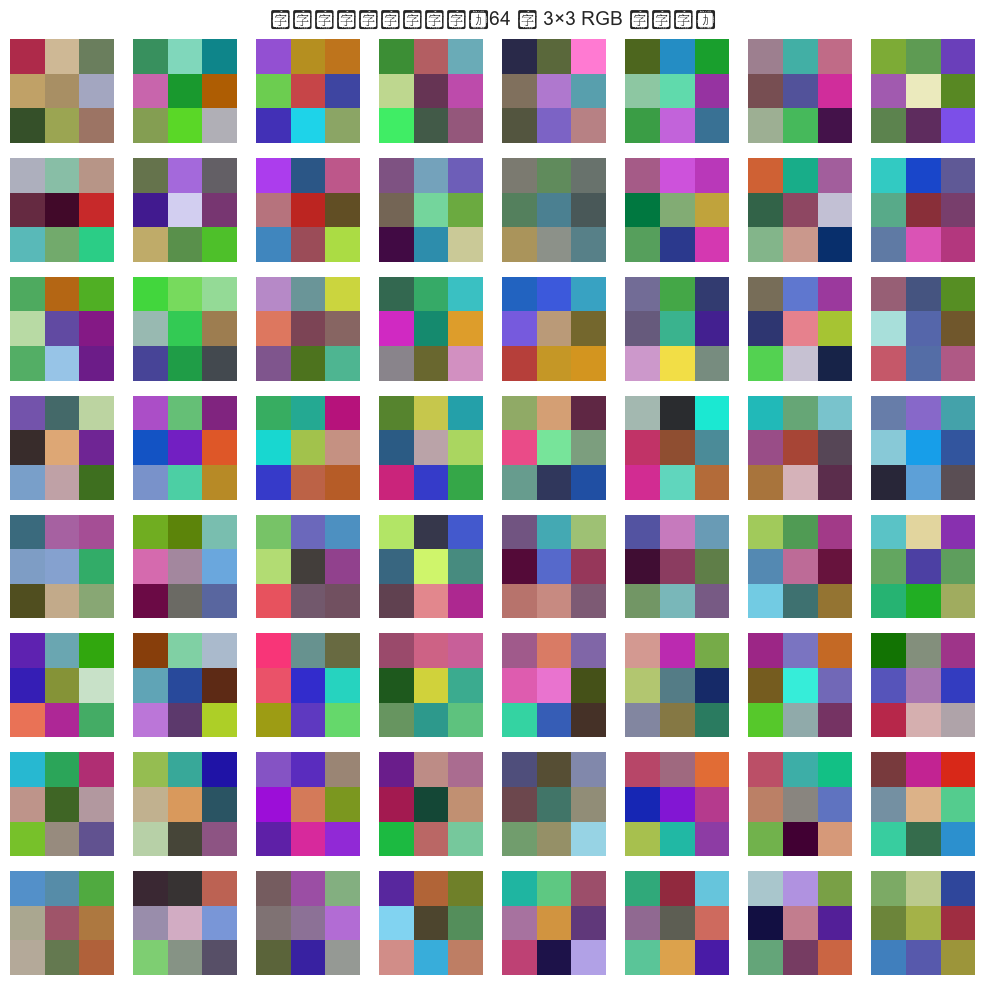

In [18]:
# 第一层卷积权重 [64,3,3,3]
w = cnn_model.block1.conv1.weight.detach().cpu()
w_min, w_max = w.min(), w.max()
w_norm = (w - w_min) / (w_max - w_min + 1e-8)  # 归一化到 0-1 便于显示
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(w_norm[i].permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("第一层卷积核可视化（64 个 3×3 RGB 卷积核）", fontsize=14)
plt.tight_layout(); plt.show()

#### 6.5.3 特征图可视化

通过 **forward hook** 抓取某张测试图像经过各卷积块后的特征图，
观察网络逐层提取的特征（浅层偏纹理/边缘，深层偏语义）。

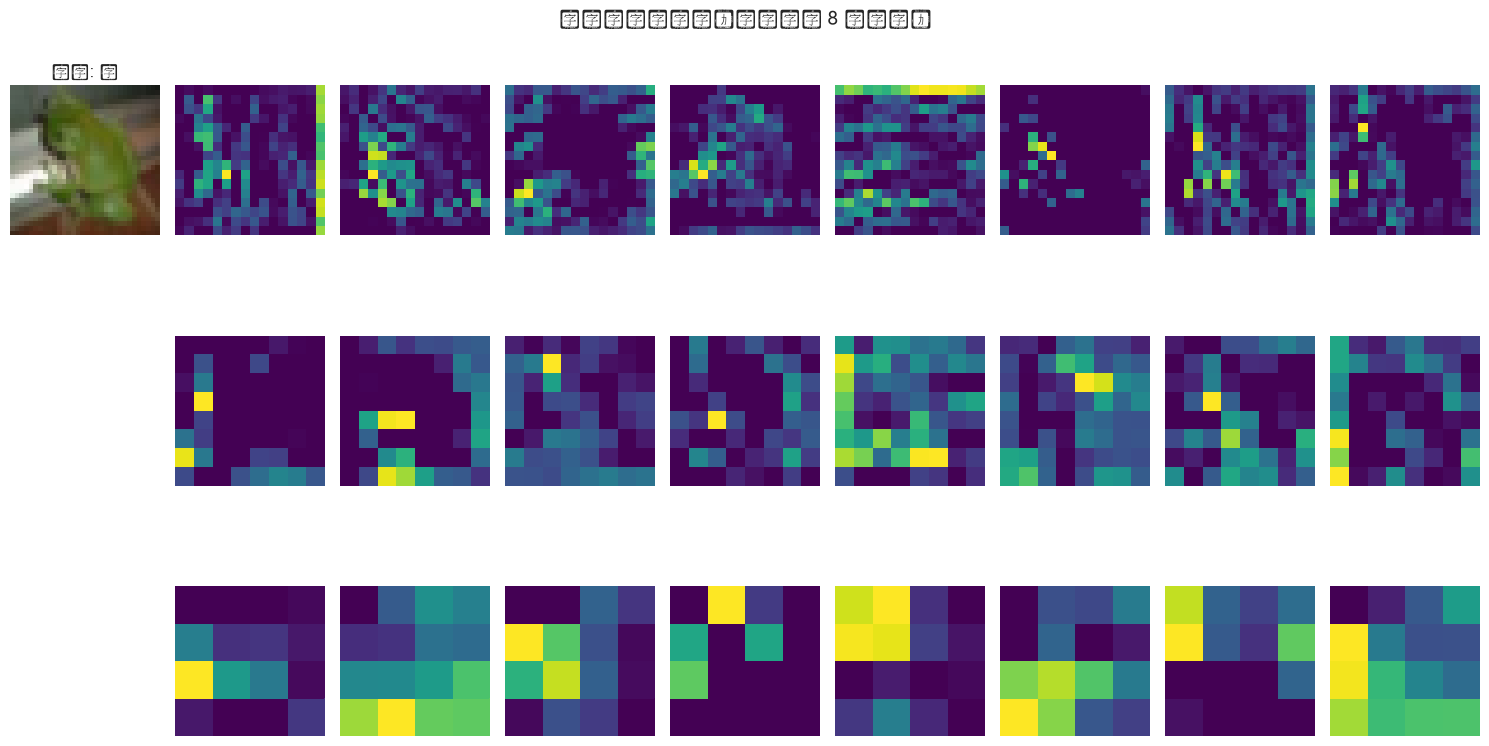

In [19]:
# 注册 hook 抓取每个 block 的输出
feature_maps = {}
def make_hook(name):
    def hook(module, inp, out):
        feature_maps[name] = out.detach().cpu()
    return hook
h1 = cnn_model.block1.register_forward_hook(make_hook("block1"))
h2 = cnn_model.block2.register_forward_hook(make_hook("block2"))
h3 = cnn_model.block3.register_forward_hook(make_hook("block3"))

# 选一张测试图
sample_img, sample_label = test_set[7]
cnn_model.eval()
with torch.no_grad():
    _ = cnn_model(sample_img.unsqueeze(0).to(device))
h1.remove(); h2.remove(); h3.remove()

# 反归一化用于显示原图
def denorm(t):
    t = t.clone()
    for c in range(3):
        t[c] = t[c] * STD[c] + MEAN[c]
    return t.permute(1, 2, 0).clamp(0, 1).numpy()

fig = plt.figure(figsize=(15, 8))
ax0 = plt.subplot2grid((3, 9), (0, 0))
ax0.imshow(denorm(sample_img)); ax0.set_title(f"原图: {CLASSES_CN[sample_label]}")
ax0.axis("off")
for row, bname in enumerate(["block1", "block2", "block3"]):
    fmap = feature_maps[bname][0]  # [C,H,W]
    for k in range(8):
        ax = plt.subplot2grid((3, 9), (row, k + 1))
        ax.imshow(fmap[k].numpy(), cmap="viridis"); ax.axis("off")
        if k == 0:
            ax.set_ylabel(bname, rotation=0, labelpad=25, fontsize=11)
plt.suptitle("各卷积块特征图（每块取前 8 个通道）", fontsize=14)
plt.tight_layout(); plt.show()

#### 6.5.4 注意力热力图（CBAM 空间注意力）

CBAM 的空间注意力图反映网络认为图像中**哪些区域最重要**。
下面取若干测试图像，将 Block1 的空间注意力图上采样到原图尺寸并叠加显示。
亮（红）区域表示注意力权重高，即模型重点关注的位置。

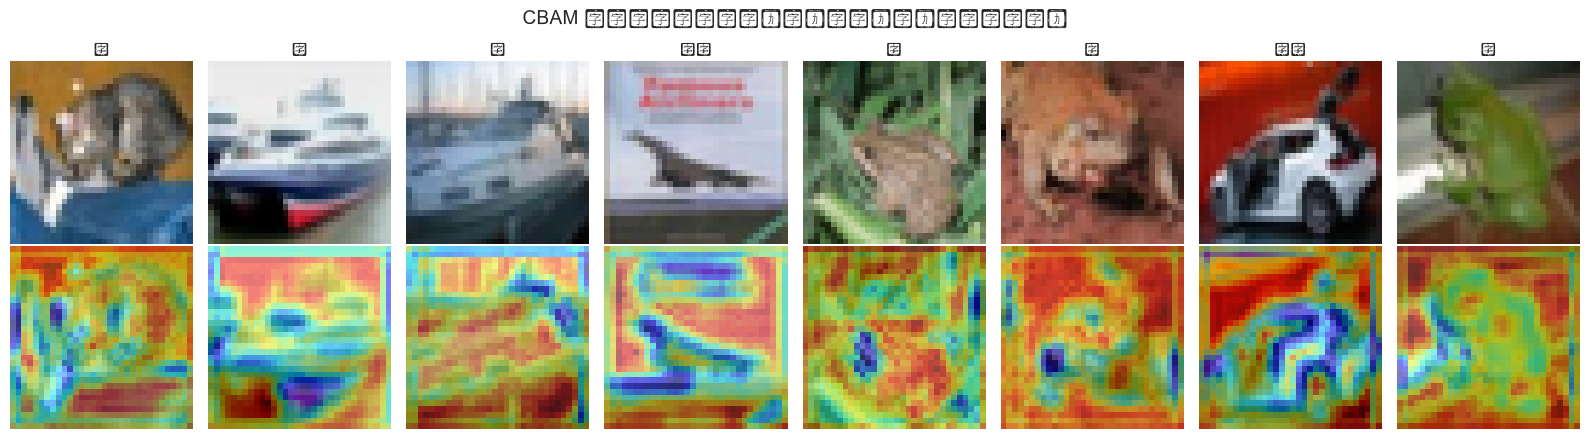

In [20]:
import torch.nn.functional as F2

def get_attention_overlay(model, img_tensor):
    '''前向一次，取 block1 的 CBAM 空间注意力图'''
    model.eval()
    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(device))
    att = model.block1.cbam.last_spatial_att[0, 0].cpu()  # [H,W]
    att = F2.interpolate(att[None, None], size=(32, 32),
                         mode="bilinear", align_corners=False)[0, 0]
    att = (att - att.min()) / (att.max() - att.min() + 1e-8)
    return att.numpy()

# 取每类一张正确分类的样本
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
shown = 0
for idx in range(len(test_set)):
    if shown >= 8: break
    img, label = test_set[idx]
    pred = y_pred[idx]
    if pred != label: continue
    att = get_attention_overlay(cnn_model, img)
    orig = denorm(img)
    axes[0, shown].imshow(orig); axes[0, shown].axis("off")
    axes[0, shown].set_title(CLASSES_CN[label], fontsize=10)
    axes[1, shown].imshow(orig)
    axes[1, shown].imshow(att, cmap="jet", alpha=0.5)
    axes[1, shown].axis("off")
    shown += 1
axes[0, 0].set_ylabel("原图", rotation=0, labelpad=25);
axes[1, 0].set_ylabel("注意力", rotation=0, labelpad=25)
plt.suptitle("CBAM 空间注意力热力图（上：原图，下：注意力叠加）", fontsize=14)
plt.tight_layout(); plt.show()

#### 6.5.5 错误样本分析

展示模型误判的典型样本，分析其真实标签、预测标签及预测置信度，
有助于理解模型的失败模式（如外形相似的猫狗、鸟飞机等）。

测试集误判样本总数: 1030 / 10000 (错误率 0.103)


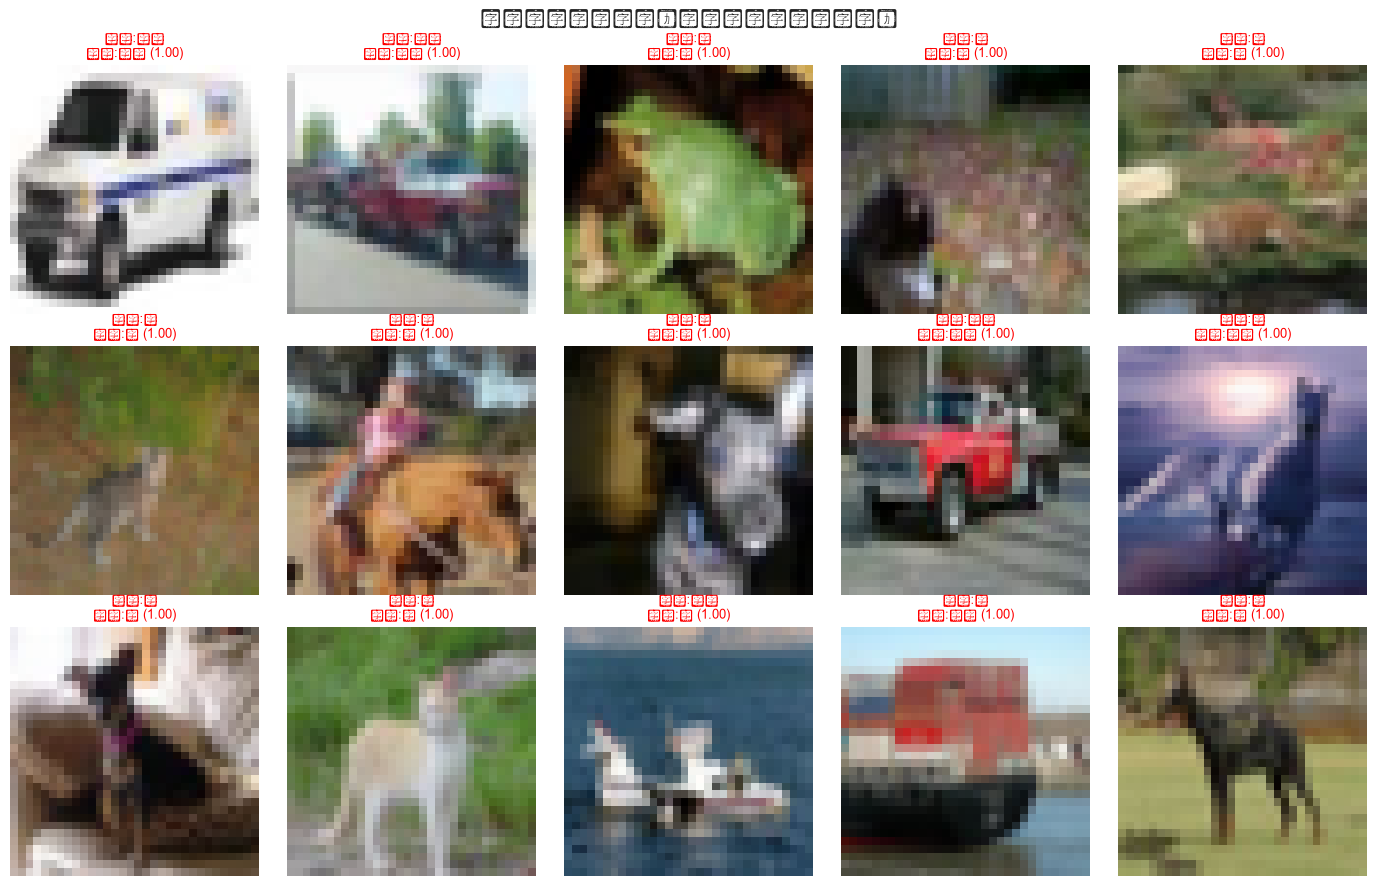

In [21]:
# 找出误判样本
wrong_idx = np.where(y_pred != y_true)[0]
print(f"测试集误判样本总数: {len(wrong_idx)} / {len(y_true)} "
      f"(错误率 {len(wrong_idx)/len(y_true):.3f})")

# 取前 15 个误判样本展示（按置信度排序，挑模型最"自信"却错的）
conf_wrong = y_prob[wrong_idx, y_pred[wrong_idx]]
order = wrong_idx[np.argsort(-conf_wrong)][:15]
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
for ax, idx in zip(axes.flat, order):
    img, _ = test_set[idx]
    ax.imshow(denorm(img)); ax.axis("off")
    ax.set_title(f"真实:{CLASSES_CN[y_true[idx]]}\n预测:{CLASSES_CN[y_pred[idx]]} "
                 f"({y_prob[idx, y_pred[idx]]:.2f})", fontsize=9, color="red")
plt.suptitle("高置信度误判样本（模型很自信但判错了）", fontsize=14)
plt.tight_layout(); plt.show()